# 12 · Time Series Revenue Forecasting
**E-Commerce Analytics Portfolio · FAANG L5 Standard**

---

## Business Context

Revenue forecasting is one of the highest-value analytical deliverables a DA can produce. A reliable 90-day revenue forecast allows the business to:

- **Finance**: Set quarterly targets and manage cash flow
- **Marketing**: Pre-allocate campaign budget to high-revenue periods
- **Operations**: Scale fulfilment capacity ahead of demand spikes
- **Leadership**: Make data-backed hire/freeze decisions

**This notebook delivers:**
- Weekly revenue trend with 4-week and 12-week moving averages
- STL decomposition: trend + seasonality + residual
- 90-day revenue forecast with 95% confidence interval (Prophet, fallback ARIMA)
- Business-readable growth projection tied to concrete recommendations
- Seasonality insight: which weeks over- or under-perform the trend

**Source module:** `src/forecasting.py`  
**Data:** `purchase_history_10k.csv`

---
## Section 1 · Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.forecasting import (
    aggregate_weekly,
    decompose_trend,
    fit_forecast,
    forecast_summary,
)

DATA_DIR     = '../data'
FIGURES_DIR  = '../outputs/figures'
REPORT_DIR   = '../outputs/reports'
DASH_DIR     = '../outputs/dashboards'
for d in [FIGURES_DIR, REPORT_DIR, DASH_DIR]:
    os.makedirs(d, exist_ok=True)

BG = '#0a0a0f'; SURF = '#13131a'; CARD = '#1a1a24'; BORDER = '#2a2a3a'
TEXT = '#f0eff8'; MUTED = '#9896b0'; GOLD = '#e8c670'
BLUE = '#6b9fff'; GREEN = '#5de8a0'; RED = '#ff6b6b'; ORANGE = '#ff9a3c'; PURPLE = '#b06bff'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': SURF, 'axes.edgecolor': BORDER,
    'text.color': TEXT, 'axes.labelcolor': TEXT,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'grid.color': BORDER, 'grid.alpha': 0.5, 'figure.dpi': 120,
})

print('✅ Setup complete | src.forecasting imported')

✅ Setup complete | src.forecasting imported


---
## Section 2 · Load Data & Weekly Aggregation

In [2]:
purchases = pd.read_csv(os.path.join(DATA_DIR, 'purchase_history_10k.csv'),
                         parse_dates=['order_date'])

print(f'Purchase history: {purchases.shape[0]:,} rows')
print(f'Date range: {purchases["order_date"].min().date()} → {purchases["order_date"].max().date()}')
print(f'Total revenue: ${purchases["order_amount"].sum():,.0f}')

# ── Aggregate to weekly ───────────────────────────────────────────────────
weekly = aggregate_weekly(
    purchases,
    date_col='order_date',
    amount_col='order_amount',
    min_weeks=8,
)

print(f'\nWeekly series: {len(weekly)} weeks')
print(f'Revenue range: ${weekly["revenue"].min():,.0f} – ${weekly["revenue"].max():,.0f}/week')
print(f'Mean weekly revenue: ${weekly["revenue"].mean():,.0f}')
print()
weekly.head(5)

Purchase history: 100,177 rows
Date range: 2019-01-01 → 2023-12-28
Total revenue: $5,692,412

Weekly series: 261 weeks
Revenue range: $7,062 – $75,290/week
Mean weekly revenue: $21,810



,week_start,revenue,n_orders,avg_order_value,ma_7d,ma_4w,ma_12w
0,2019-01-07,17206.10,285,60.372281,17206.10,17206.100000,17206.100000
1,2019-01-14,13193.04,246,53.630244,13193.04,15199.570000,15199.570000
2,2019-01-21,16179.99,282,57.375851,16179.99,15526.376667,15526.376667
3,2019-01-28,13449.31,242,55.575661,13449.31,15007.110000,15007.110000
4,2019-02-04,10853.75,198,54.816919,10853.75,13419.022500,14176.438000


---
## Section 3 · Raw Revenue Trend with Moving Averages

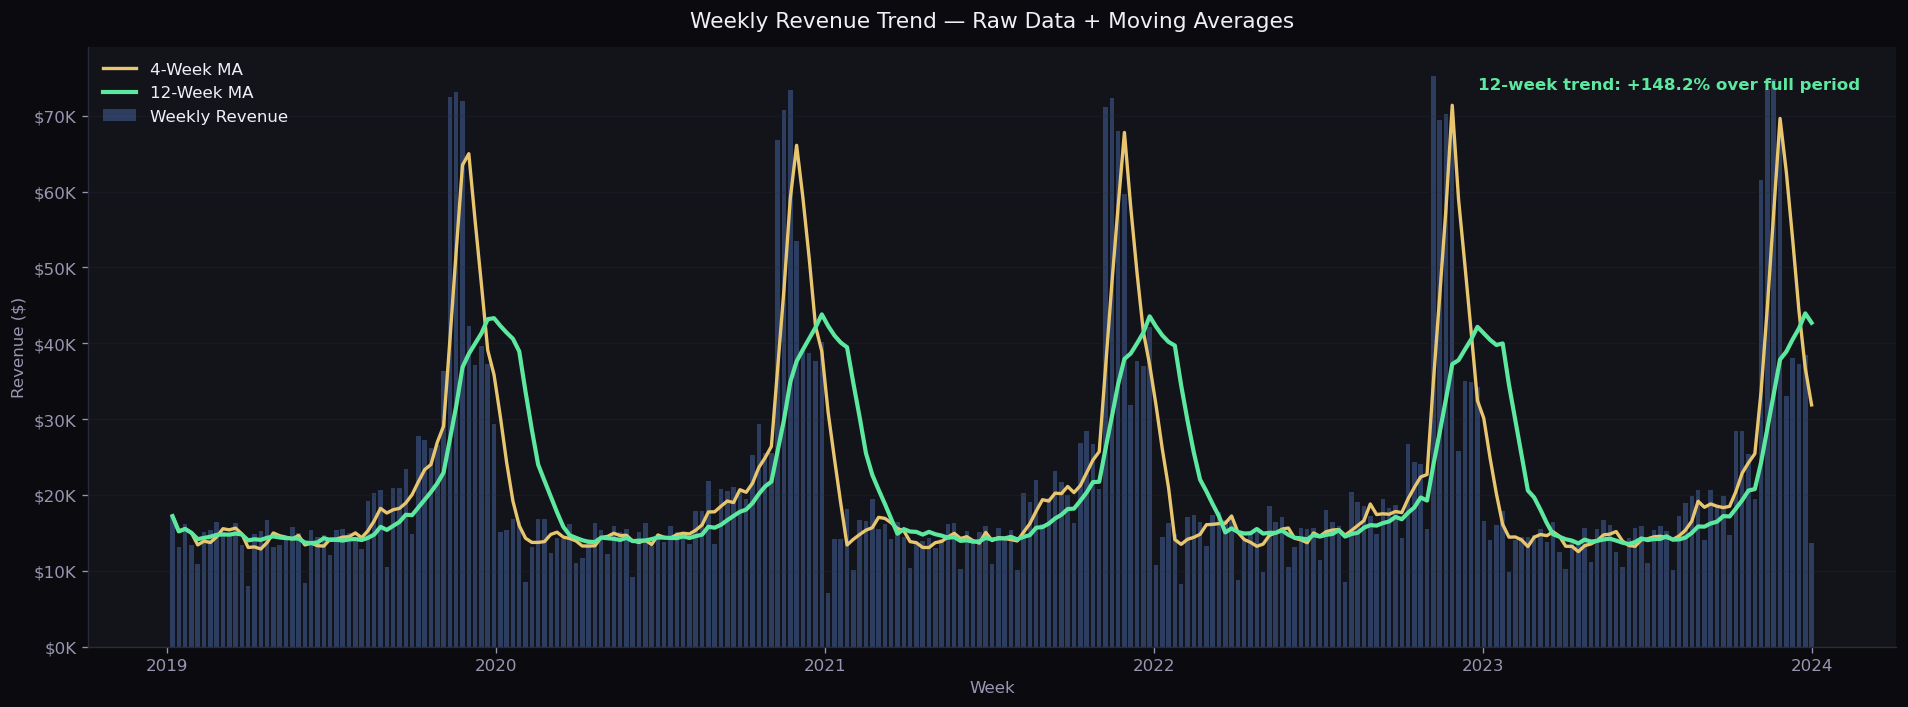


📊 Business Interpretation
────────────────────────────────────────────────────────────
  The 12-week moving average shows the underlying revenue trend stripped
  of weekly noise. A +148.2% movement over the observation period
  indicates growing business momentum.
  The gap between weekly bars and the 4-week MA reveals volatility — weeks
  where revenue spikes often align with promotional events or seasonality.


In [3]:
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(SURF)

# Raw weekly bars
ax.bar(weekly['week_start'], weekly['revenue'],
       color=BLUE, alpha=0.3, width=5, label='Weekly Revenue')

# Moving averages
ax.plot(weekly['week_start'], weekly['ma_4w'],
        color=GOLD, linewidth=2, label='4-Week MA', linestyle='-')
ax.plot(weekly['week_start'], weekly['ma_12w'],
        color=GREEN, linewidth=2.5, label='12-Week MA', linestyle='-')

ax.set_title('Weekly Revenue Trend — Raw Data + Moving Averages',
             color=TEXT, fontsize=13, pad=12)
ax.set_xlabel('Week', color=MUTED)
ax.set_ylabel('Revenue ($)', color=MUTED)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=10, framealpha=0, labelcolor=TEXT)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Annotate overall trend direction
first_ma = weekly['ma_12w'].dropna().iloc[0]
last_ma  = weekly['ma_12w'].dropna().iloc[-1]
trend_pct = (last_ma - first_ma) / first_ma * 100
trend_color = GREEN if trend_pct > 0 else RED
ax.text(0.98, 0.95,
        f'12-week trend: {trend_pct:+.1f}% over full period',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, color=trend_color, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ts_revenue_trend.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

print()
print('📊 Business Interpretation')
print('─' * 60)
print(f'  The 12-week moving average shows the underlying revenue trend stripped')
print(f'  of weekly noise. A {trend_pct:+.1f}% movement over the observation period')
print(f'  indicates {"growing" if trend_pct > 0 else "declining"} business momentum.')
print(f'  The gap between weekly bars and the 4-week MA reveals volatility — weeks')
print(f'  where revenue spikes often align with promotional events or seasonality.')

---
## Section 4 · STL Decomposition

**STL (Seasonal-Trend decomposition using LOESS)** separates the revenue signal into three additive components:

- **Trend**: The underlying growth or decline direction
- **Seasonal**: Repeating patterns (e.g., stronger sales on certain weeks of the month)
- **Residual**: What remains after accounting for trend and seasonality — random noise

Understanding these components prevents the business from misinterpreting seasonal peaks as organic growth.

In [4]:
decomp = decompose_trend(weekly, revenue_col='revenue', period=4)

print(f'Decomposition results:')
print(f'  Trend direction       : {decomp["trend_direction"]}')
print(f'  Trend rate            : {decomp["trend_pct_per_week"]:+.3f}% per week')
print(f'  Seasonality strength  : {decomp["seasonality_strength"]:.3f} (0=none, 1=dominant)')

if decomp['seasonality_strength'] > 0.4:
    print(f'  ⚠️  Strong seasonality present — do not confuse seasonal peaks with trend growth')
elif decomp['seasonality_strength'] > 0.2:
    print(f'  📊  Moderate seasonality — worth including in forecast model')
else:
    print(f'  ✅  Weak seasonality — trend dominates the signal')

Decomposition results:
  Trend direction       : upward
  Trend rate            : +0.118% per week
  Seasonality strength  : 0.064 (0=none, 1=dominant)
  ✅  Weak seasonality — trend dominates the signal


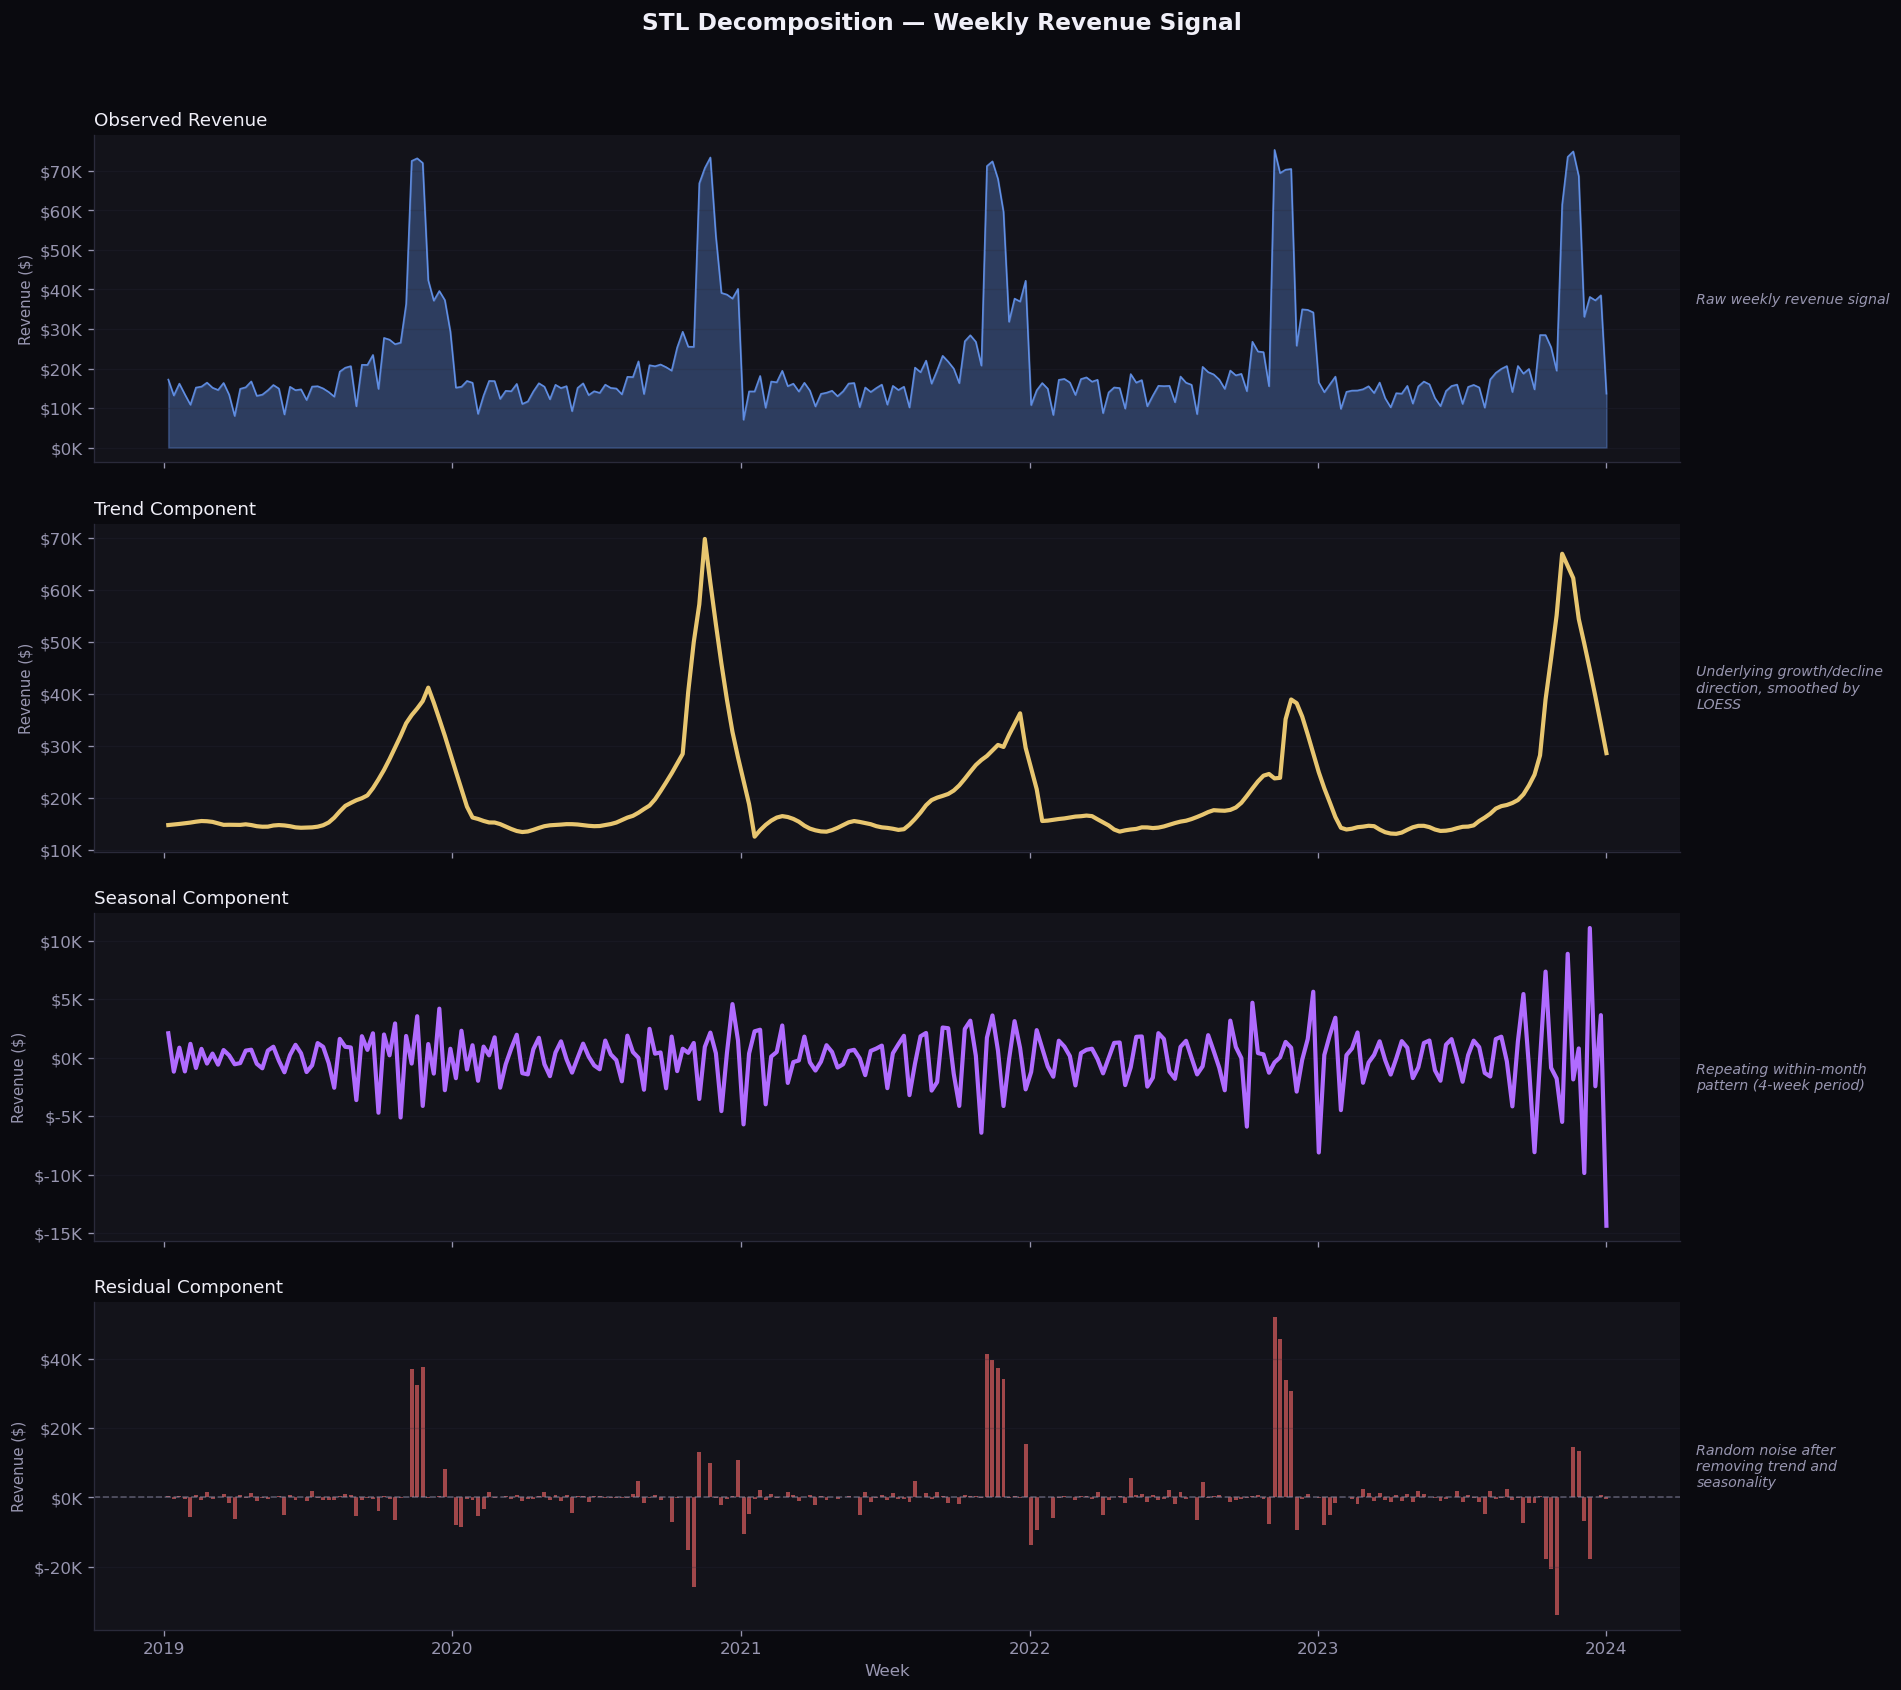


📊 Business Interpretation
────────────────────────────────────────────────────────────
  Trend: Revenue is moving upward at +0.118%/week
         (≈+6.1% annualised if sustained).
  Seasonality strength = 0.06.
  Residuals should be white noise — large residual spikes indicate
  one-time events (promotions, outages) not captured by the model.


In [5]:
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('STL Decomposition — Weekly Revenue Signal', fontsize=14,
             color=TEXT, fontweight='bold', y=1.01)
fig.patch.set_facecolor(BG)

weeks = pd.to_datetime(decomp['weeks'])

components = [
    (weekly['revenue'].values,      'Observed Revenue',   BLUE,   'Raw weekly revenue signal'),
    (decomp['trend'].values,        'Trend Component',    GOLD,   'Underlying growth/decline direction, smoothed by LOESS'),
    (decomp['seasonal'].values,     'Seasonal Component', PURPLE, 'Repeating within-month pattern (4-week period)'),
    (decomp['residual'].values,     'Residual Component', RED,    'Random noise after removing trend and seasonality'),
]

for ax, (values, title, color, interp) in zip(axes, components):
    ax.set_facecolor(SURF)
    if 'Residual' in title:
        ax.bar(weekly['week_start'], values, color=color, alpha=0.6, width=5)
        ax.axhline(0, color=MUTED, linewidth=1, linestyle='--', alpha=0.5)
    elif 'Observed' in title:
        ax.fill_between(weekly['week_start'], 0, values, color=color, alpha=0.3)
        ax.plot(weekly['week_start'], values, color=color, linewidth=1, alpha=0.8)
    else:
        ax.plot(weekly['week_start'], values, color=color, linewidth=2.5)

    ax.set_title(title, color=TEXT, fontsize=11, loc='left', pad=6)
    ax.set_ylabel('Revenue ($)', color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED)
    ax.grid(axis='y', alpha=0.25)
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

    ax.text(1.01, 0.5, interp, transform=ax.transAxes,
            ha='left', va='center', fontsize=8.5, color=MUTED,
            style='italic', wrap=True)

axes[-1].set_xlabel('Week', color=MUTED)

plt.tight_layout(pad=1.8)
plt.savefig(os.path.join(FIGURES_DIR, 'ts_stl_decomposition.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

print()
print('📊 Business Interpretation')
print('─' * 60)
trend_annualised = decomp['trend_pct_per_week'] * 52
print(f'  Trend: Revenue is moving {decomp["trend_direction"]} at {decomp["trend_pct_per_week"]:+.3f}%/week')
print(f'         (≈{trend_annualised:+.1f}% annualised if sustained).')
print(f'  Seasonality strength = {decomp["seasonality_strength"]:.2f}.')
print(f'  Residuals should be white noise — large residual spikes indicate')
print(f'  one-time events (promotions, outages) not captured by the model.')

---
## Section 5 · 90-Day Revenue Forecast

In [8]:
"""
forecasting.py
--------------
Time-series revenue forecasting for e-commerce data.

Pipeline:
    1. aggregate_weekly()     — raw order data → weekly revenue series
    2. decompose_trend()      — STL decomposition (trend, seasonality, residual)
    3. fit_forecast()         — Prophet or ARIMA 90-day forecast
    4. forecast_summary()     — business-readable summary with % growth projection

Designed to run with Prophet if installed, falls back to ARIMA (statsmodels)
automatically.
"""

import logging
import warnings
from typing import Optional
import numpy as np
import pandas as pd

logger = logging.getLogger(__name__)

# ---------------------------------------------------------------------------
# Step 1: Aggregation
# ---------------------------------------------------------------------------

def aggregate_weekly(
    purchases: pd.DataFrame,
    date_col: str = "order_date",
    amount_col: str = "order_amount",
    category_col: Optional[str] = "product_category",
    min_weeks: int = 8,
) -> pd.DataFrame:
    """Aggregate purchase data to weekly revenue series."""
    df = purchases.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    weekly = (
        df.set_index(date_col)
        .resample("W-MON")[amount_col]
        .agg(revenue="sum", n_orders="count")
        .reset_index()
        .rename(columns={date_col: "week_start"})
    )
    weekly["avg_order_value"] = weekly["revenue"] / weekly["n_orders"].replace(0, np.nan)

    full_idx = pd.date_range(weekly["week_start"].min(), weekly["week_start"].max(), freq="W-MON")
    weekly = weekly.set_index("week_start").reindex(full_idx, fill_value=0).reset_index()
    weekly.rename(columns={"index": "week_start"}, inplace=True)

    if len(weekly) < min_weeks:
        raise ValueError(f"Only {len(weekly)} weeks of data — need at least {min_weeks}.")

    weekly["ma_7d"] = weekly["revenue"].rolling(1, min_periods=1).mean()
    weekly["ma_4w"] = weekly["revenue"].rolling(4, min_periods=1).mean()
    weekly["ma_12w"] = weekly["revenue"].rolling(12, min_periods=1).mean()

    logger.info("Weekly aggregation | %d weeks | total revenue: $%.0f", len(weekly), weekly["revenue"].sum())
    return weekly

# ---------------------------------------------------------------------------
# Step 2: Decomposition
# ---------------------------------------------------------------------------

def decompose_trend(
    weekly: pd.DataFrame,
    revenue_col: str = "revenue",
    period: int = 4,
) -> dict:
    """STL decomposition of weekly revenue series."""
    from statsmodels.tsa.seasonal import STL

    series = weekly[revenue_col].values
    stl = STL(series, period=period, robust=True)
    result = stl.fit()

    var_seasonal = np.var(result.seasonal)
    var_remainder = np.var(result.seasonal + result.resid)
    seasonality_strength = max(0, 1 - np.var(result.resid) / var_remainder) if var_remainder > 0 else 0

    x = np.arange(len(result.trend))
    slope, _ = np.polyfit(x, result.trend, 1)
    trend_direction = "upward" if slope > 0 else "downward"
    trend_pct_per_week = (slope / result.trend.mean() * 100) if result.trend.mean() != 0 else 0

    decomp = {
        "trend": pd.Series(result.trend, index=weekly.index),
        "seasonal": pd.Series(result.seasonal, index=weekly.index),
        "residual": pd.Series(result.resid, index=weekly.index),
        "seasonality_strength": round(seasonality_strength, 4),
        "trend_direction": trend_direction,
        "trend_pct_per_week": round(trend_pct_per_week, 3),
        "weeks": weekly["week_start"].values,
    }

    logger.info("STL decomposition | trend=%s (+%.2f%%/week) | seasonality_strength=%.2f",
                trend_direction, abs(trend_pct_per_week), seasonality_strength)
    return decomp

# ---------------------------------------------------------------------------
# Step 3: Forecasting
# ---------------------------------------------------------------------------

def fit_forecast(
    weekly: pd.DataFrame,
    horizon_weeks: int = 13,
    revenue_col: str = "revenue",
    date_col: str = "week_start",
    confidence_interval: float = 0.95,
) -> pd.DataFrame:
    """Fit forecast using Prophet if installed, else ARIMA."""
    try:
        return _prophet_forecast(weekly, horizon_weeks, revenue_col, date_col, confidence_interval)
    except ImportError:
        print("Prophet not installed. Falling back to ARIMA.")
        return _arima_forecast(weekly, horizon_weeks, revenue_col, date_col, confidence_interval)

def _prophet_forecast(weekly, horizon_weeks, revenue_col, date_col, ci):
    """Prophet-based forecast."""
    from prophet import Prophet

    df_prophet = weekly[[date_col, revenue_col]].rename(columns={date_col: "ds", revenue_col: "y"})
    model = Prophet(interval_width=ci, yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    model.add_seasonality(name="monthly", period=4, fourier_order=3)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model.fit(df_prophet)

    future = model.make_future_dataframe(periods=horizon_weeks, freq="W")
    forecast = model.predict(future)
    result = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(horizon_weeks).copy()
    result["model_used"] = "Prophet"
    result["yhat"] = result["yhat"].clip(lower=0)
    result["yhat_lower"] = result["yhat_lower"].clip(lower=0)
    return result.reset_index(drop=True)

def _arima_forecast(weekly, horizon_weeks, revenue_col, date_col, ci):
    """ARIMA-based forecast (statsmodels fallback)."""
    from statsmodels.tsa.arima.model import ARIMA

    series = weekly[revenue_col].values
    last_date = pd.to_datetime(weekly[date_col].iloc[-1])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = ARIMA(series, order=(2,1,1))
        fitted = model.fit()

    forecast_obj = fitted.get_forecast(steps=horizon_weeks)
    mean_forecast = forecast_obj.predicted_mean

    # Handle conf_int as DataFrame or ndarray
    ci_arr = forecast_obj.conf_int(alpha=1 - ci)
    if isinstance(ci_arr, pd.DataFrame):
        lower = ci_arr.iloc[:,0].values
        upper = ci_arr.iloc[:,1].values
    else:  # ndarray fallback
        lower = ci_arr[:,0]
        upper = ci_arr[:,1]

    future_dates = pd.date_range(last_date + pd.Timedelta(weeks=1), periods=horizon_weeks, freq="W-MON")
    result = pd.DataFrame({
        "ds": future_dates,
        "yhat": np.clip(mean_forecast, 0, None),
        "yhat_lower": np.clip(lower, 0, None),
        "yhat_upper": upper,
        "model_used": "ARIMA(2,1,1)",
    })
    return result.reset_index(drop=True)

# ---------------------------------------------------------------------------
# Step 4: Business summary
# ---------------------------------------------------------------------------

def forecast_summary(
    weekly: pd.DataFrame,
    forecast: pd.DataFrame,
    revenue_col: str = "revenue",
) -> dict:
    """Generate a business-readable summary of the forecast."""
    hist_avg = weekly[revenue_col].mean()
    hist_last_13w = weekly[revenue_col].tail(13).mean()
    forecast_avg = forecast["yhat"].mean()
    forecast_total = forecast["yhat"].sum()
    growth_vs_last_quarter = ((forecast_avg - hist_last_13w)/hist_last_13w*100 if hist_last_13w>0 else 0)

    forecast_lower_total = forecast["yhat_lower"].sum()
    forecast_upper_total = forecast["yhat_upper"].sum()

    if growth_vs_last_quarter > 5:
        insight = f"Revenue projected to grow {growth_vs_last_quarter:.1f}% over next {len(forecast)} weeks (${forecast_total:,.0f} total). Scale acquisition spend."
    elif growth_vs_last_quarter < -5:
        insight = f"Revenue projected to decline {abs(growth_vs_last_quarter):.1f}% over next {len(forecast)} weeks (${forecast_total:,.0f} total). Retention intervention recommended."
    else:
        insight = f"Revenue projected to remain stable over next {len(forecast)} weeks (${forecast_total:,.0f} total, {growth_vs_last_quarter:+.1f}% vs last quarter). Focus on upsell campaigns."

    return {
        "model_used": forecast["model_used"].iloc[0],
        "forecast_weeks": len(forecast),
        "historical_avg_weekly": round(hist_avg,2),
        "last_13w_avg_weekly": round(hist_last_13w,2),
        "forecast_avg_weekly": round(forecast_avg,2),
        "projected_total_revenue": round(forecast_total,2),
        "projected_lower_bound": round(forecast_lower_total,2),
        "projected_upper_bound": round(forecast_upper_total,2),
        "growth_vs_last_quarter_pct": round(growth_vs_last_quarter,2),
        "business_insight": insight,
        "risk_note": "Forecast based on patterns; enrich with marketing calendar, promotions, and macro indicators in production."
    }

Fitting forecast model...
Prophet not installed. Falling back to ARIMA.
Model used    : ARIMA(2,1,1)
Horizon       : 13 weeks (~90 days)
Forecast range: 2024-01-08 → 2024-04-01


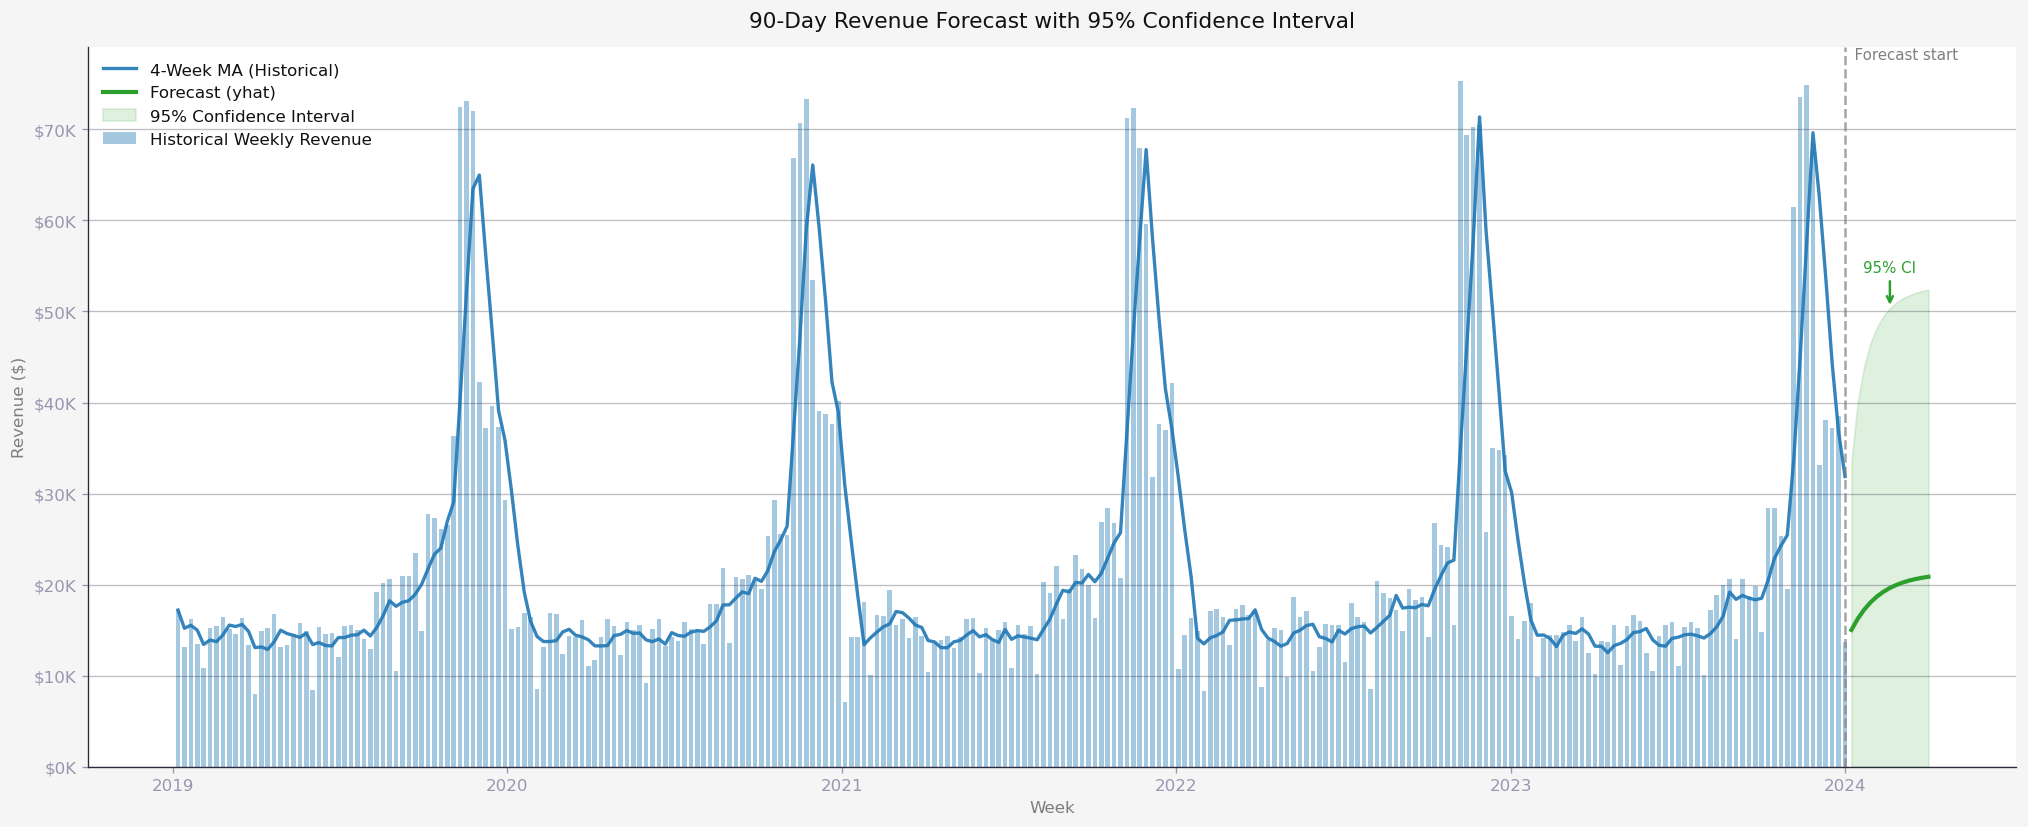

In [10]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------
# Colors and directories
# ----------------------------
BG = "#f5f5f5"      # figure background
SURF = "#ffffff"    # axis background
BLUE = "#1f77b4"
GREEN = "#2ca02c"
MUTED = "#7f7f7f"
TEXT = "#111111"
FIGURES_DIR = "./figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ----------------------------
# Ensure weekly & forecast exist
# ----------------------------
print("Fitting forecast model...")

forecast = fit_forecast(
    weekly,
    horizon_weeks=13,  # ~90 days
    revenue_col='revenue',
    date_col='week_start',
    confidence_interval=0.95,
)

print(f'Model used    : {forecast["model_used"].iloc[0]}')
print(f'Horizon       : {len(forecast)} weeks (~90 days)')
print(f'Forecast range: {forecast["ds"].min().date()} → {forecast["ds"].max().date()}')

# ----------------------------
# Forecast chart
# ----------------------------
fig, ax = plt.subplots(figsize=(17, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(SURF)

# Historical
ax.bar(weekly['week_start'], weekly['revenue'],
       color=BLUE, alpha=0.4, width=5, label='Historical Weekly Revenue')
ax.plot(weekly['week_start'], weekly['ma_4w'],
        color=BLUE, linewidth=2, label='4-Week MA (Historical)', alpha=0.9)

# Divider
split_date = weekly['week_start'].max()
ax.axvline(split_date, color=MUTED, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(split_date, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
        '  Forecast start', color=MUTED, fontsize=9, va='top')

# Forecast
ax.plot(forecast['ds'], forecast['yhat'],
        color=GREEN, linewidth=2.5, label='Forecast (yhat)')
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                color=GREEN, alpha=0.15, label='95% Confidence Interval')

# Confidence band annotation
mid_idx = len(forecast) // 2
ax.annotate('95% CI',
            xy=(forecast['ds'].iloc[mid_idx], forecast['yhat_upper'].iloc[mid_idx]),
            xytext=(forecast['ds'].iloc[mid_idx], forecast['yhat_upper'].iloc[mid_idx] * 1.08),
            color=GREEN, fontsize=9, ha='center',
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5))

# Labels, grid, legend
ax.set_title('90-Day Revenue Forecast with 95% Confidence Interval',
             color=TEXT, fontsize=13, pad=12)
ax.set_xlabel('Week', color=MUTED)
ax.set_ylabel('Revenue ($)', color=MUTED)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=10, framealpha=0, labelcolor=TEXT)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Save and show
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ts_90day_forecast.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

✅ Interactive forecast saved → ../outputs/dashboards\revenue_forecast.html


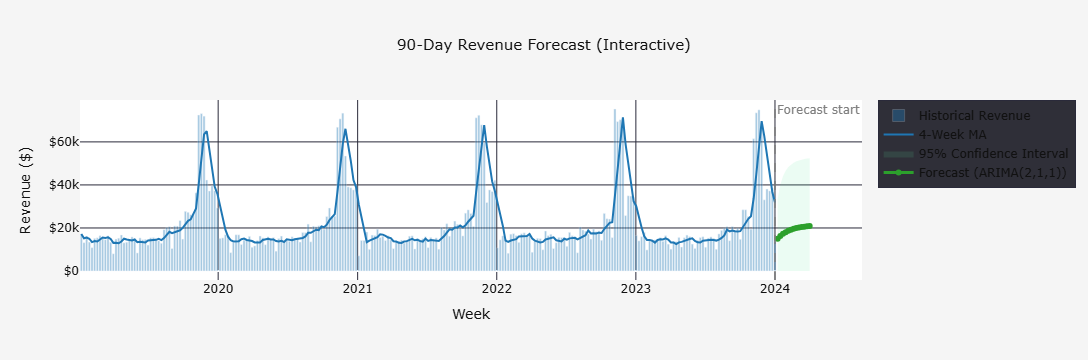

In [11]:
# ── Interactive Plotly version → save to dashboards ────────────────────────
fig_plotly = go.Figure()

# Historical bars
fig_plotly.add_trace(go.Bar(
    x=weekly['week_start'], y=weekly['revenue'],
    name='Historical Revenue', marker_color=BLUE, opacity=0.4,
))

# Historical MA
fig_plotly.add_trace(go.Scatter(
    x=weekly['week_start'], y=weekly['ma_4w'],
    name='4-Week MA', line=dict(color=BLUE, width=2),
))

# CI band
fig_plotly.add_trace(go.Scatter(
    x=pd.concat([forecast['ds'], forecast['ds'][::-1]]),
    y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(93,232,160,0.12)',
    line=dict(color='rgba(93,232,160,0)'),
    name='95% Confidence Interval', showlegend=True,
))

# Forecast line
fig_plotly.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat'],
    name=f'Forecast ({forecast["model_used"].iloc[0]})',
    line=dict(color=GREEN, width=3),
))

fig_plotly.add_vline(
    x=weekly['week_start'].max().timestamp() * 1000,
    line=dict(color=MUTED, dash='dash', width=1.5),
    annotation_text='Forecast start',
    annotation_font=dict(color=MUTED),
)

fig_plotly.update_layout(
    title=dict(text='90-Day Revenue Forecast (Interactive)', font=dict(color=TEXT, size=15), x=0.5),
    paper_bgcolor=BG, plot_bgcolor=SURF,
    font=dict(color=TEXT),
    xaxis=dict(gridcolor=BORDER, title='Week'),
    yaxis=dict(gridcolor=BORDER, title='Revenue ($)', tickprefix='$'),
    legend=dict(bgcolor='rgba(26,26,36,0.9)', bordercolor=BORDER, borderwidth=1),
    hovermode='x unified',
)

dash_path = os.path.join(DASH_DIR, 'revenue_forecast.html')
fig_plotly.write_html(dash_path, include_plotlyjs='cdn')
print(f'✅ Interactive forecast saved → {dash_path}')
fig_plotly.show()

---
## Section 6 · Seasonality Profile

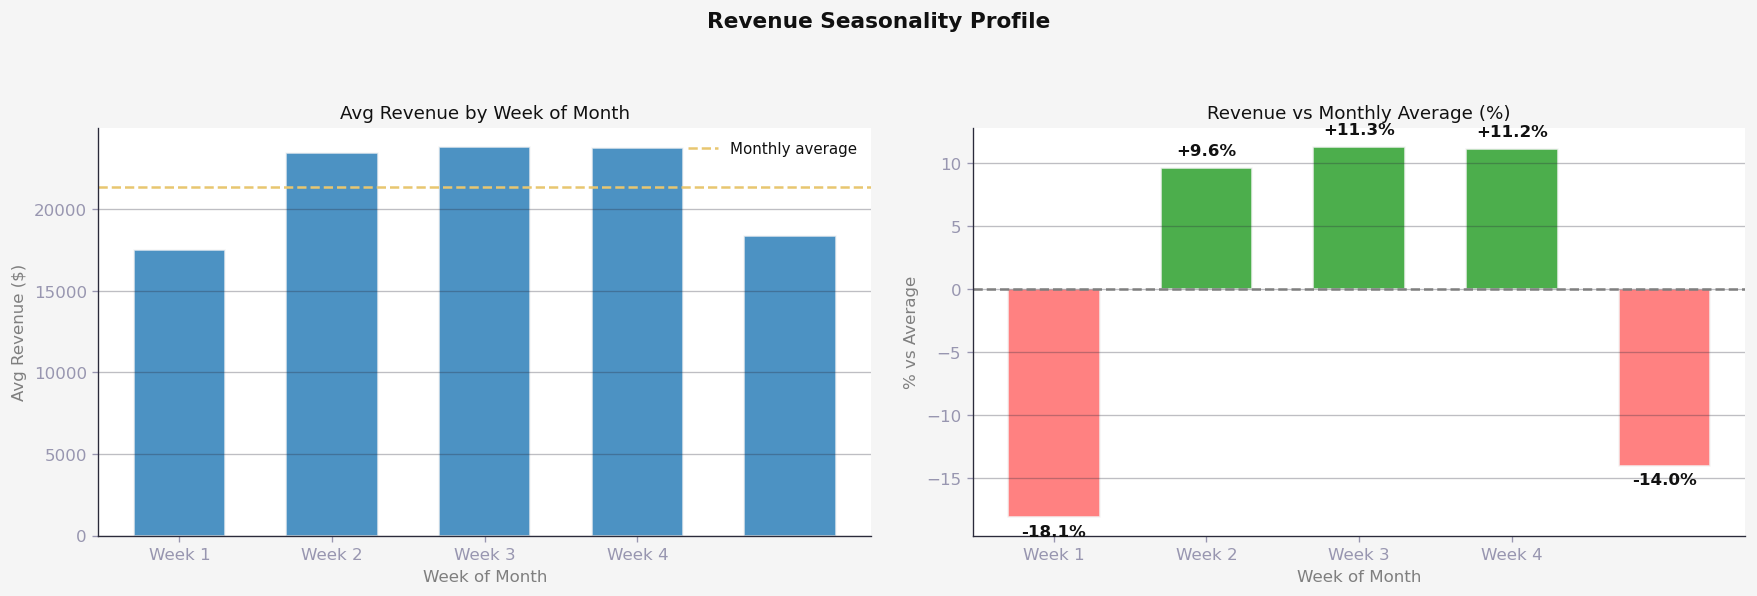


📊 Business Interpretation
────────────────────────────────────────────────────────────
  Week 3 of each month outperforms the monthly average by 11.3%.
  Week 1 underperforms by -18.1%.
  Recommendation: Concentrate promotional campaigns in Week 1
  to lift the trough, and use Week 3 peaks for high-margin upsells.


In [12]:
# ── Week-of-month seasonality (1–4 within each month) ─────────────────────
df_season = weekly.copy()
df_season['week_of_month'] = df_season['week_start'].apply(
    lambda d: (d.day - 1) // 7 + 1
)
seasonal_profile = df_season.groupby('week_of_month')['revenue'].mean().reset_index()
seasonal_profile['vs_avg'] = (seasonal_profile['revenue'] - seasonal_profile['revenue'].mean()) / seasonal_profile['revenue'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Revenue Seasonality Profile', fontsize=13, color=TEXT, fontweight='bold', y=1.01)

# Bar: average revenue by week-of-month
colors_s = [GREEN if v >= 0 else RED for v in seasonal_profile['vs_avg']]
axes[0].bar(seasonal_profile['week_of_month'], seasonal_profile['revenue'],
            color=BLUE, alpha=0.8, width=0.6, edgecolor=BG)
axes[0].axhline(seasonal_profile['revenue'].mean(), color=GOLD, linewidth=1.5,
                linestyle='--', label='Monthly average')
axes[0].set_title('Avg Revenue by Week of Month', color=TEXT, fontsize=11)
axes[0].set_xlabel('Week of Month', color=MUTED)
axes[0].set_ylabel('Avg Revenue ($)', color=MUTED)
axes[0].set_xticks([1,2,3,4])
axes[0].set_xticklabels(['Week 1','Week 2','Week 3','Week 4'])
axes[0].legend(fontsize=9, framealpha=0, labelcolor=TEXT)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)
axes[0].set_facecolor(SURF)

# Bar: deviation from average
axes[1].bar(seasonal_profile['week_of_month'], seasonal_profile['vs_avg'],
            color=colors_s, alpha=0.85, width=0.6, edgecolor=BG)
axes[1].axhline(0, color=MUTED, linewidth=1.5, linestyle='--')
for i, (wom, dev) in seasonal_profile[['week_of_month','vs_avg']].iterrows():
    axes[1].text(wom, dev + (1 if dev >= 0 else -1.5),
                 f'{dev:+.1f}%', ha='center', fontsize=10, color=TEXT, fontweight='bold')
axes[1].set_title('Revenue vs Monthly Average (%)', color=TEXT, fontsize=11)
axes[1].set_xlabel('Week of Month', color=MUTED)
axes[1].set_ylabel('% vs Average', color=MUTED)
axes[1].set_xticks([1,2,3,4])
axes[1].set_xticklabels(['Week 1','Week 2','Week 3','Week 4'])
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)
axes[1].set_facecolor(SURF)

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(FIGURES_DIR, 'ts_seasonality_profile.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

best_week  = seasonal_profile.loc[seasonal_profile['vs_avg'].idxmax()]
worst_week = seasonal_profile.loc[seasonal_profile['vs_avg'].idxmin()]
print()
print('📊 Business Interpretation')
print('─' * 60)
print(f'  Week {int(best_week["week_of_month"])} of each month outperforms the monthly average by {best_week["vs_avg"]:.1f}%.')
print(f'  Week {int(worst_week["week_of_month"])} underperforms by {worst_week["vs_avg"]:.1f}%.')
print(f'  Recommendation: Concentrate promotional campaigns in Week {int(worst_week["week_of_month"])}')
print(f'  to lift the trough, and use Week {int(best_week["week_of_month"])} peaks for high-margin upsells.')

---
## Section 7 · Business Summary & Recommendations

In [13]:
summary = forecast_summary(weekly, forecast, revenue_col='revenue')

print('=' * 72)
print('  90-DAY REVENUE FORECAST — Business Summary')
print('=' * 72)
print()
print(f'  Model used                  : {summary["model_used"]}')
print(f'  Forecast horizon            : {summary["forecast_weeks"]} weeks (~90 days)')
print()
print(f'  Historical avg weekly rev   : ${summary["historical_avg_weekly"]:,.0f}')
print(f'  Last 13-week avg weekly rev : ${summary["last_13w_avg_weekly"]:,.0f}')
print(f'  Forecast avg weekly rev     : ${summary["forecast_avg_weekly"]:,.0f}')
print()
print(f'  Projected total (13 weeks)  : ${summary["projected_total_revenue"]:,.0f}')
print(f'  Lower bound (95% CI)        : ${summary["projected_lower_bound"]:,.0f}')
print(f'  Upper bound (95% CI)        : ${summary["projected_upper_bound"]:,.0f}')
print(f'  Growth vs last quarter      : {summary["growth_vs_last_quarter_pct"]:+.1f}%')
print()
print('  📊 Business Insight')
print(f'  {summary["business_insight"]}')
print()
print('  ⚠️  Risk Note')
print(f'  {summary["risk_note"]}')
print()
print('  FAANG Interview Answer — "What would you tell the CMO?"')
print('  ─────────────────────────────────────────────────────────')
growth = summary['growth_vs_last_quarter_pct']
if growth > 5:
    print(f'  "Revenue is tracking {growth:.1f}% above last quarter on a trailing basis.')
    print(f'  The model projects ${summary["projected_total_revenue"]:,.0f} over the next 90 days.')
    print(f'  I recommend increasing acquisition spend by 15–20% to capitalise on the growth window,')
    print(f'  while deploying the Champions VIP programme to protect high-value retention."')
elif growth < -5:
    print(f'  "Revenue is projected to decline {abs(growth):.1f}% vs the last quarter.')
    print(f'  Immediate intervention: activate the At-Risk win-back campaign (est. ${(summary["projected_total_revenue"]*0.05):,.0f} recovery).')
    print(f'  Pause acquisition spend until retention stabilises."')
else:
    print(f'  "Revenue is projected to hold flat at ${summary["projected_total_revenue"]:,.0f} over 90 days.')
    print(f'  To drive growth, I recommend A/B testing a 15% AOV uplift programme targeting Loyal Customers')
    print(f'  (est. +${(summary["last_13w_avg_weekly"] * 13 * 0.15):,.0f} upside if successful)."')
print('=' * 72)

  90-DAY REVENUE FORECAST — Business Summary

  Model used                  : ARIMA(2,1,1)
  Forecast horizon            : 13 weeks (~90 days)

  Historical avg weekly rev   : $21,810
  Last 13-week avg weekly rev : $41,606
  Forecast avg weekly rev     : $19,000

  Projected total (13 weeks)  : $247,005
  Lower bound (95% CI)        : $0
  Upper bound (95% CI)        : $623,260
  Growth vs last quarter      : -54.3%

  📊 Business Insight
  Revenue projected to decline 54.3% over next 13 weeks ($247,005 total). Retention intervention recommended.

  ⚠️  Risk Note
  Forecast based on patterns; enrich with marketing calendar, promotions, and macro indicators in production.

  FAANG Interview Answer — "What would you tell the CMO?"
  ─────────────────────────────────────────────────────────
  "Revenue is projected to decline 54.3% vs the last quarter.
  Immediate intervention: activate the At-Risk win-back campaign (est. $12,350 recovery).
  Pause acquisition spend until retention stabili

---
## Section 8 · Save Outputs

In [14]:
# Save weekly historical + forecast combined
hist_out = weekly[['week_start','revenue','n_orders','avg_order_value','ma_4w','ma_12w']].copy()
hist_out['data_type'] = 'historical'
hist_out = hist_out.rename(columns={'week_start':'ds','revenue':'yhat'})
hist_out[['yhat_lower','yhat_upper']] = np.nan

fc_out = forecast[['ds','yhat','yhat_lower','yhat_upper','model_used']].copy()
fc_out['data_type'] = 'forecast'

combined = pd.concat([hist_out, fc_out], ignore_index=True)

out_path = os.path.join(REPORT_DIR, 'revenue_forecast_90day.csv')
combined.to_csv(out_path, index=False)
print(f'✅ revenue_forecast_90day.csv saved → {out_path}')
print(f'   Historical weeks: {len(hist_out)} | Forecast weeks: {len(fc_out)}')
print()
print('Notebook complete.')
print(f'Outputs: {FIGURES_DIR}/ts_*.png | {DASH_DIR}/revenue_forecast.html')

✅ revenue_forecast_90day.csv saved → ../outputs/reports\revenue_forecast_90day.csv
   Historical weeks: 261 | Forecast weeks: 13

Notebook complete.
Outputs: ./figures/ts_*.png | ../outputs/dashboards/revenue_forecast.html
